In [1]:
%load_ext autoreload
%autoreload
import os, copy, h5py
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import numpy as np
import pandas as pd
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir
from compas_python_utils.cosmic_integration.ClassCOMPAS import COMPASData
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023, madau_dickinson_sfr
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022, compas_log_skew_normal_distribution_metallicity_distribution
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.cosmology_utils import lookback_time_to_redshift
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict
import matplotlib.pyplot as plt
import time
import warnings
import scipy
from scipy import stats
from get_ZdepSFRD import skew_metallicity_distribution, Madau_Dickinson2014
from population_vis import get_formation_efficiency
import logging

1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  eff_ax.legend()
/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:173: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  eff_fig.show()


Took 0.36145877838134766 to find efficiencies


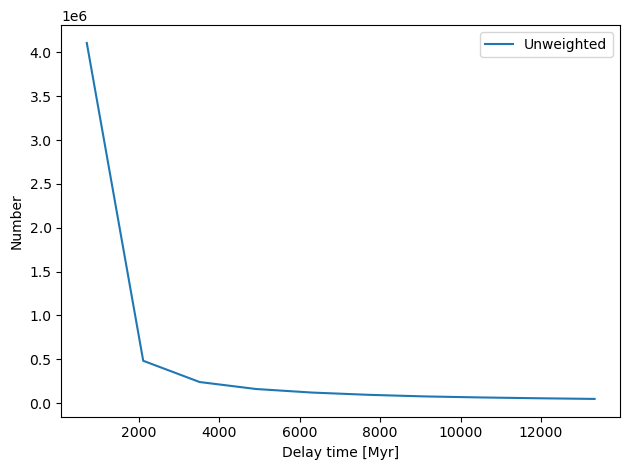

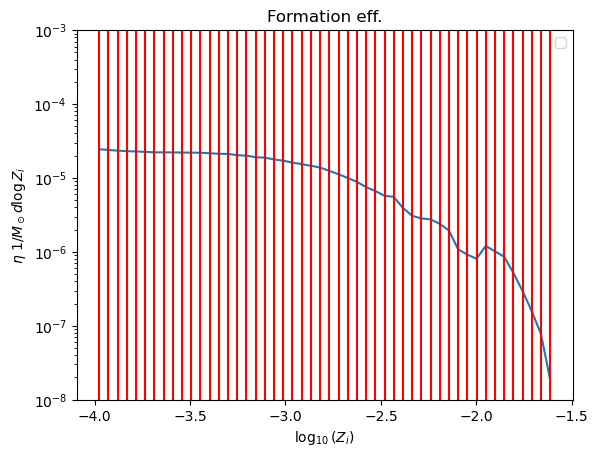

In [2]:
filepath = '/Volumes/Elements/Boesky_sims.h5'

# SET UP DATA -- from a basic dict, port to an h5 file and then store this into the output file
# now we want to use some real data
fdata = h5py.File(filepath)
all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
# potentially mask with/without a stable mass transfer or without an envelope
mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
fdata.close()
TYPES = 'BBH'
fe_binned, fe_bins, compasdata = get_formation_efficiency(filepath, types=TYPES)
delayTimes = compasdata.delayTimes

# need to get the metallicities as well
dco_query = np.isin(all_seeds, all_dco_seeds[compasdata.DCOmask])
dco_metallicities = metallicities[dco_query]
# dco_mixture_weight = mixture_weight[dco_query]
assert len(delayTimes[()]) == len(dco_metallicities), "Something went wrong with masking for dco metallicities"
# to query the probabilties, we can digitize the fe_kde using the dco metallicities
# or just use the kde directly -- TODO: maybe one way is more true than the other?
start_time = time.time()
#dco_efficiencies = fe_kde(dco_metallicities) # this is WAY too slow, have to use bins
dfe_logZ = np.digitize(np.log10(dco_metallicities), (fe_bins[:-1]+fe_bins[1:])/2) - 1
dco_efficiencies = fe_binned[dfe_logZ]
print(f'Took {time.time() - start_time} to find efficiencies')

In [3]:
mu_0 = 0.024793657773309900
mu_z = -0.05209823762263910
omega_0 = 1.1509042383700300
omega_z = 0.04765044123610770
alpha = -1.8801262733286600
a_sfr = 0.017190526975713500
b_sfr = 1.442486560339300
c_sfr = 4.529877338746180
d_sfr = 6.226058519122930

# mu_0 = 0.024793657773309900
# mu_z = -0.05209823762263910
# omega_0 = 1.1509042383700300
# omega_z = 0.04765044123610770
# alpha = -1.8801262733286600
# a_sfr = 0.01
# b_sfr = 2.6
# c_sfr = 3.2
# d_sfr = 6.2

In [4]:
def setup_output_file(folder_path, filename):
    """Create boilerplate output file for convolution."""
    output_hdf5_filename = os.path.join(folder_path, filename)
    generate_boilerplate_outputfile(output_hdf5_filename)
    return output_hdf5_filename, folder_path


def copy_input_data_to_output(folder_path, output_hdf5_filename):
    """Copy minimal required input data into the output file."""

    example_data = {
        "delay_time": delayTimes[()]*u.Myr,
        "metallicity": dco_metallicities,
        "number_per_solar_mass_values": dco_efficiencies
        #"m1": df['m1'].values,
        #"m2": df['m2'].values,
    }
    example_df = pd.DataFrame.from_records(example_data)
    example_df.to_hdf(output_hdf5_filename, key="input_data/growl")

def setup_convolution_config(output_hdf5_filename, output_hdf5_folder, sfr_dict):
    """Prepare the convolution configuration dictionary."""
    convolution_config = copy.copy(default_convolution_config)
    convolution_config['logger'].setLevel(logging.WARNING)

    convolution_config["redshift_interpolator_data_output_filename"] = os.path.join(
        output_hdf5_folder, "interpolator_dict.p"
    )
    print('output_hdf5_folder', output_hdf5_folder)
    print('output_hdf5_filename', output_hdf5_filename)
    
    convolution_config["multiply_by_time_binsize"] = False
    convolution_config["time_type"] = "redshift"
    convolution_config["output_filename"] = output_hdf5_filename

    convolution_config["convolution_instructions"] = [
        {
            **default_convolution_instruction,
            "convolution_type": "integrate",
            "input_data_name": "growl",
            "output_data_name": "intrinsic",
            "data_column_dict": {
                "normalized_yield": "number_per_solar_mass_values",
                "delay_time": {"column_name": "delay_time", "unit": u.Myr},
                "metallicity": "metallicity"
            },
        },
    ]

    # Here: only care about local universe
    convolution_config["convolution_redshift_bin_edges"] = np.arange(0, 20, 2)
    convolution_config["SFR_info"] = sfr_dict

    return convolution_config

def plot_sfr(sfr_dict):
    """Plot the SFR + metallicity distribution."""
    
    
    print(f"Making a plot of the S(Z,z) you are using as a sanity check")

    axis_dict = plot_sfr_dict(
        sfr_dict,
        time_type="redshift",
        metallicity_string="logZ",
        metallicity_distribution_multiply_by_metallicity_bin_sizes=False,
        metallicity_distribution_multiply_by_sfr=True,
        metallicity_distribution_scale="log10",
        metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
        return_axis_dict=True,
        figsize=(8, 8),
        fontsize=12,
    )
    axis_dict['ax_mssfr'].set_yscale('log')
    #axis_dict['ax_mssfr'].set_ylim([1e-6, 1])
    plt.show()

def setup_sfr_dict():
    # _, log_metallicity_bin_edges = np.histogram(np.log(metallicities), bins=nbins, density=True)
    # log_metallicity_bin_centers = (log_metallicity_bin_edges[:-1] + log_metallicity_bin_edges[1:]) / 2
    # log_metallicity_bin_edges = np.log(np.logspace(min(log_metallicities), max(log_metallicities), 100))
    # print(log_metallicity_bin_edges)
    # log_metallicity_bin_centers = calculate_bincenters(log_metallicity_bin_edges)

    # metallicity_bin_centers = np.exp(log_metallicity_bin_centers)
    # metallicity_bin_edges = np.exp(log_metallicity_bin_edges)

    # Redshift bins
    #redshift_bin_edges = np.linspace(redshift_min, redshift_max, num_redshift_bins)
    redshiftlimandstep=[0, 14.1, 0.05]
    redshift_bin_centers = np.arange(redshiftlimandstep[0], redshiftlimandstep[1], redshiftlimandstep[2])
    redshift_bin_edges = calculate_bin_edges(redshift_bin_centers)

    log_metallicity_bin_edges = np.linspace(-10, 0.03, 501) 
    log_metallicity_bin_centers = calculate_bincenters(log_metallicity_bin_edges)
    metallicity_bin_centers = np.exp(log_metallicity_bin_centers)
    metallicity_bin_edges = np.exp(log_metallicity_bin_edges)

    from get_ZdepSFRD import skew_metallicity_distribution, Madau_Dickinson2014
    
    sfrd = Madau_Dickinson2014(redshift_bin_centers, a=a_sfr, b=b_sfr, c=c_sfr, d=d_sfr).to(u.Msun/u.yr/u.Gpc**3)

    dPdlogZ, metallicities, step_logZ, p_draw_metallicity = skew_metallicity_distribution(redshift_bin_centers , mu_0 = mu_0, mu_z = mu_z,
                                                  omega_0= omega_0 , omega_z=omega_z , alpha = alpha, 
                                                  metals=metallicity_bin_centers)
    metallicity_bin_sizes = np.diff(metallicity_bin_edges)

    sfrd_Z_z_fit = dPdlogZ * metallicity_bin_sizes * sfrd[:,np.newaxis].value
    
    return {
        "redshift_bin_edges": redshift_bin_edges,
        "starformation_rate_array": sfrd,
        "metallicity_bin_edges": metallicity_bin_edges,
        "metallicity_distribution_array": dPdlogZ
        #"metallicity_weighted_starformation_rate_array": sfrd_Z_z.T * metallicity_bin_sizes
    }

Making a plot of the S(Z,z) you are using as a sanity check


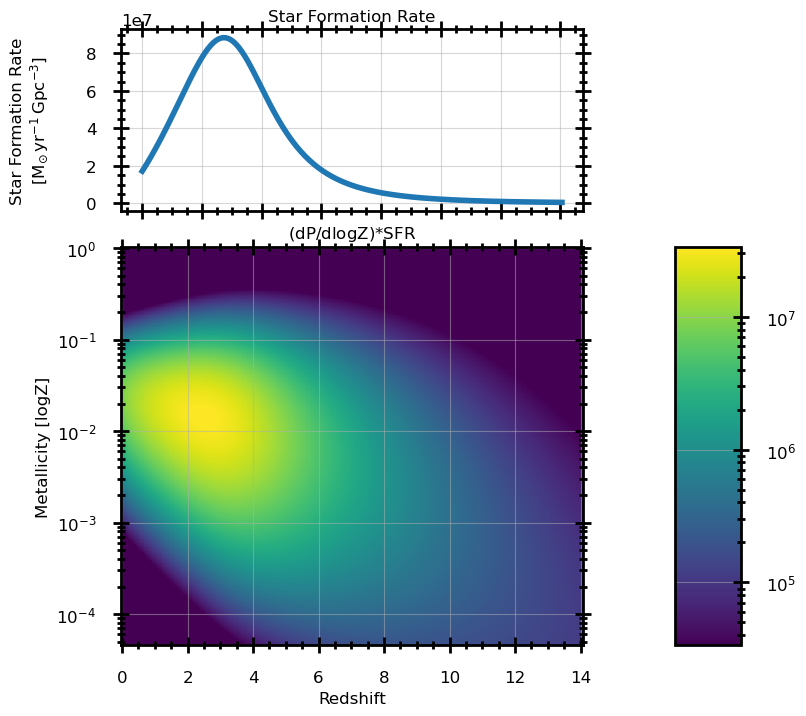

In [5]:
plot_sfr(setup_sfr_dict())

In [6]:
sfr_dict = setup_sfr_dict()
folder_path = '/Volumes/Elements/'
output_hdf5_filename, output_hdf5_folder = setup_output_file(folder_path, 'test.h5')
copy_input_data_to_output(folder_path, output_hdf5_filename)

# 4. Configure convolution
convolution_config = setup_convolution_config(
    output_hdf5_filename, output_hdf5_folder, sfr_dict)

# 5. Run convolution
convolve(config=convolution_config)

output_hdf5_folder /Volumes/Elements/
output_hdf5_filename /Volumes/Elements/test.h5


[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,511: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,541: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,569: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,595: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,623: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,650: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,680: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,700: Storing yield
[convolve_populations.py:103 - store_convolution_result_entries ] 2026-04-29 14:48:17,728: Storing yield


['1.0', '3.0', '5.0', '7.0', '9.0', '11.0', '13.0', '15.0', '17.0']
[8.33996836e+02 2.23579459e+03 1.09945708e+03 3.68070371e+02
 1.24322911e+02 4.03500283e+01 9.43480220e+00 1.15919248e-02
 1.15996717e-02]


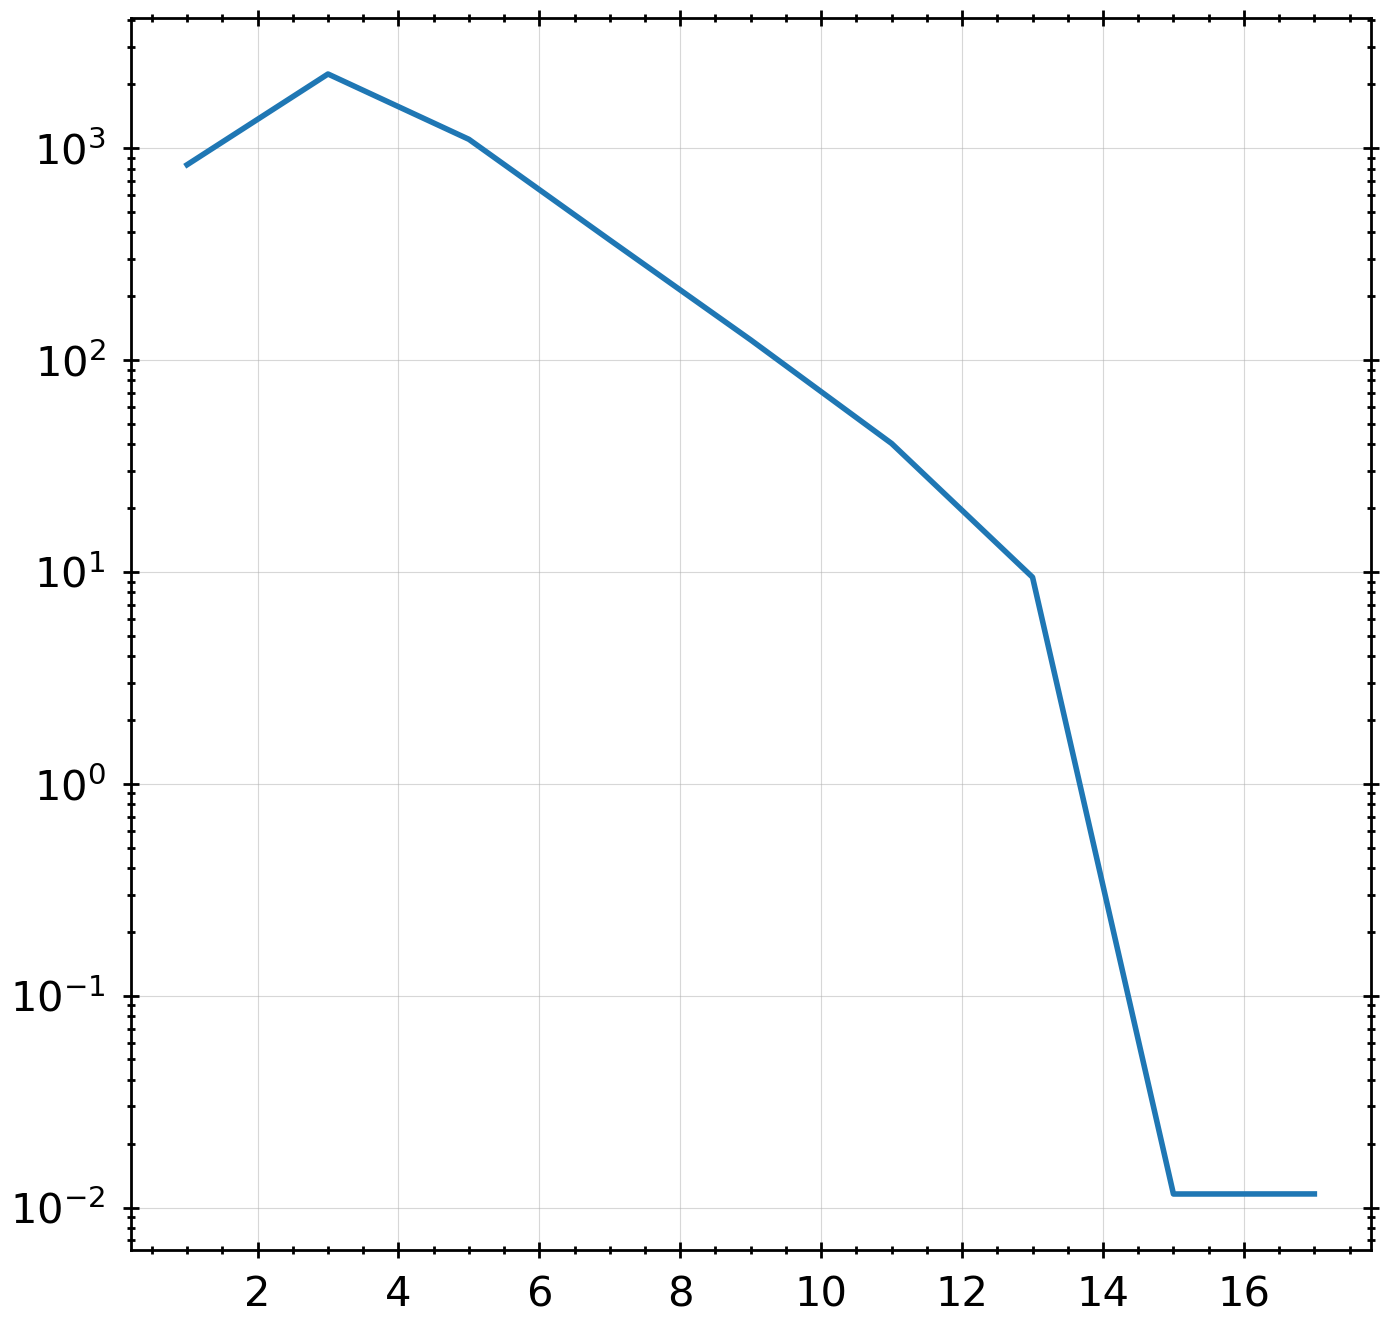

In [7]:
def read_yields(output_hdf5_filename, redshift_key="0.2"):
    # ---- Step 2: read yield_data from convolution output
    output_filename = output_hdf5_filename
    # can probably also use pd.read_hdf5 for this, but for now leaving as is 
    with h5py.File(output_filename, "r") as f:
        key = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
        yield_data = f[key + "yield"][()]
        print(f[key + "yield"])
        unit_dict = extract_unit_dict(f, key)  # optional
    return yield_data, unit_dict
# read_yields(output_hdf5_filename)

fig, ax = plt.subplots(1,1)
ax.yaxis.set_inverted(False)  # ensure not inverted

with h5py.File(output_hdf5_filename) as f:
    results_path = 'output_data/growl/intrinsic/convolution_results/'
    r_keys = f[results_path].keys()
    avail_redshifts = sorted(list(r_keys), key= lambda x: float(x))
    print(avail_redshifts)
    merger_rate = np.zeros(len(avail_redshifts))
    for i in range(len(avail_redshifts)):
        yield_array = f[results_path][avail_redshifts[i]]['yield'][()]
        assert len(yield_array) == len(dco_metallicities), "yields not matching dco filter"
        merger_rate[i] = np.sum(yield_array).astype(float)
    # for r in redshifts:
    print(merger_rate)

    # restore auto ticks/labels
    import matplotlib.ticker as mticker
    ax.yaxis.set_major_locator(mticker.AutoLocator()) #from GPT. something was wrong with matplotlib
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    # print([float(x) for x in avail_redshifts])
    # print(merger_rate)
    ax.plot([float(x) for x in avail_redshifts], merger_rate)
    ax.set_yscale('log')
    # fig.show() 

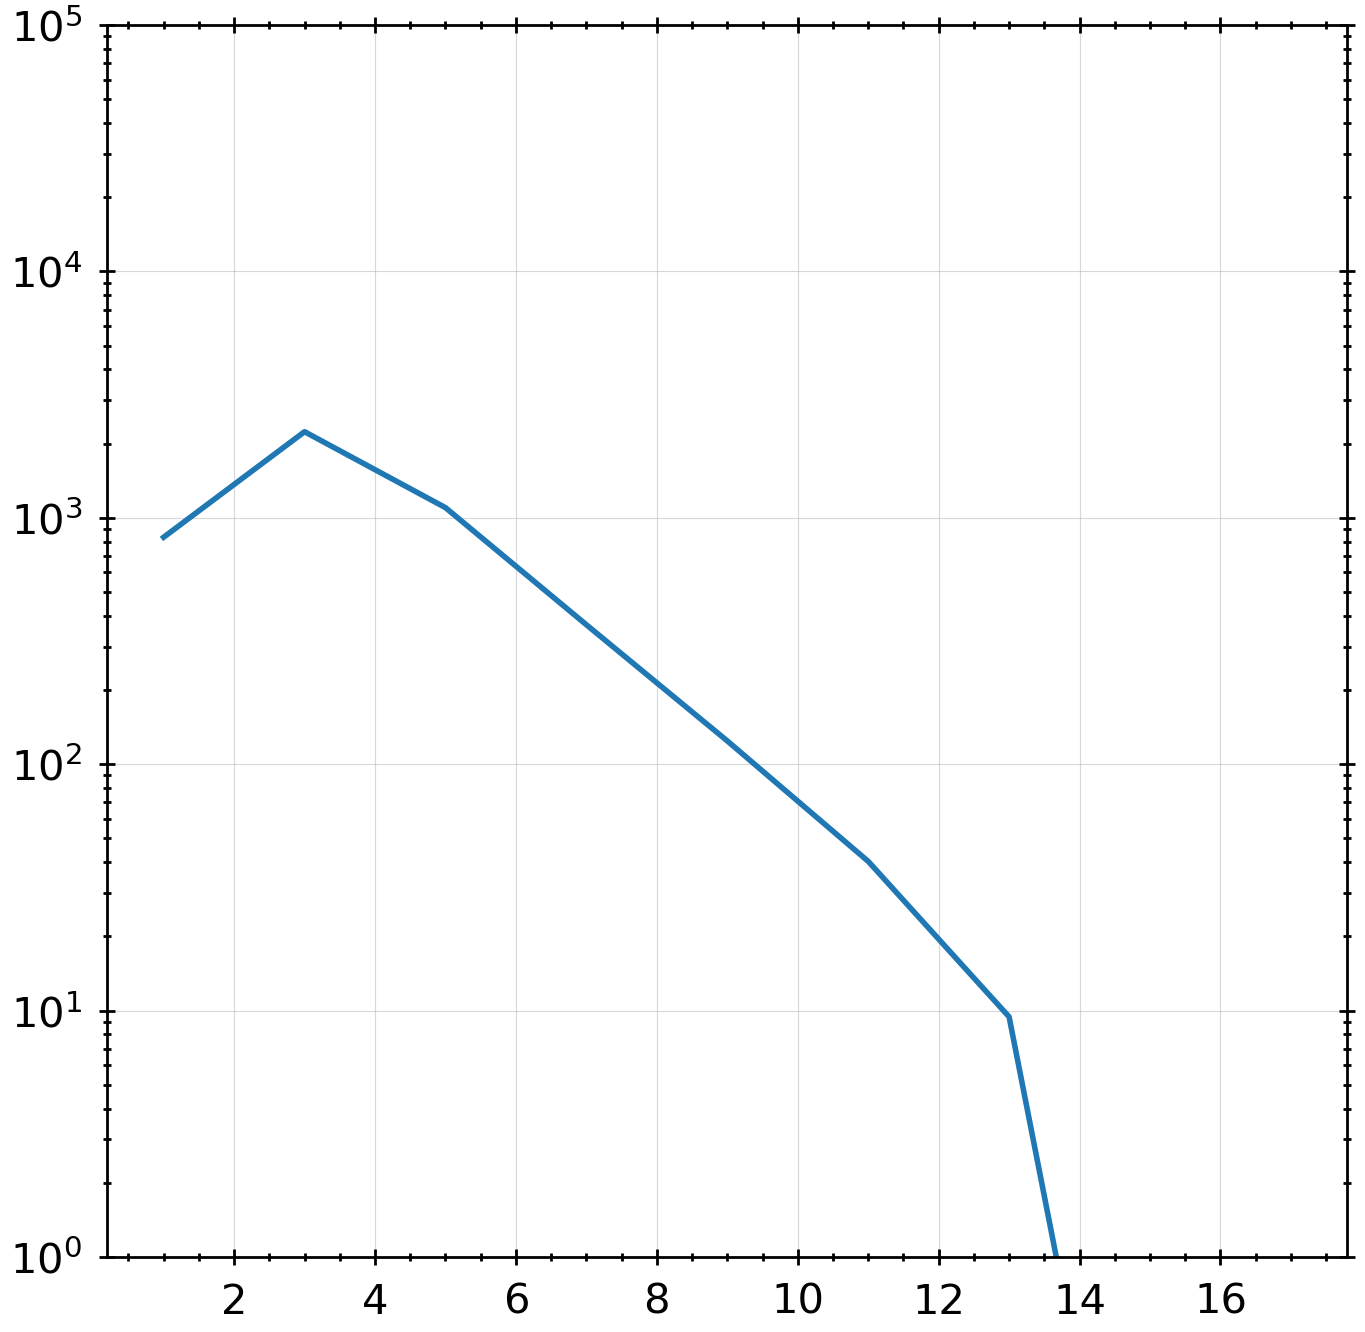

In [8]:
from shared import plot_merger_rate_from_hdf_file

fiducial_plotting_data = plot_merger_rate_from_hdf_file(
    '/Volumes/Elements/test.h5',
    'output_data/growl/intrinsic/convolution_results/',
    dco_metallicities
)
plt.figure()
plt.plot(fiducial_plotting_data['redshifts'], np.sum(fiducial_plotting_data['all_weights'],axis=0))
plt.ylim(1,10e4)
plt.yscale('log')

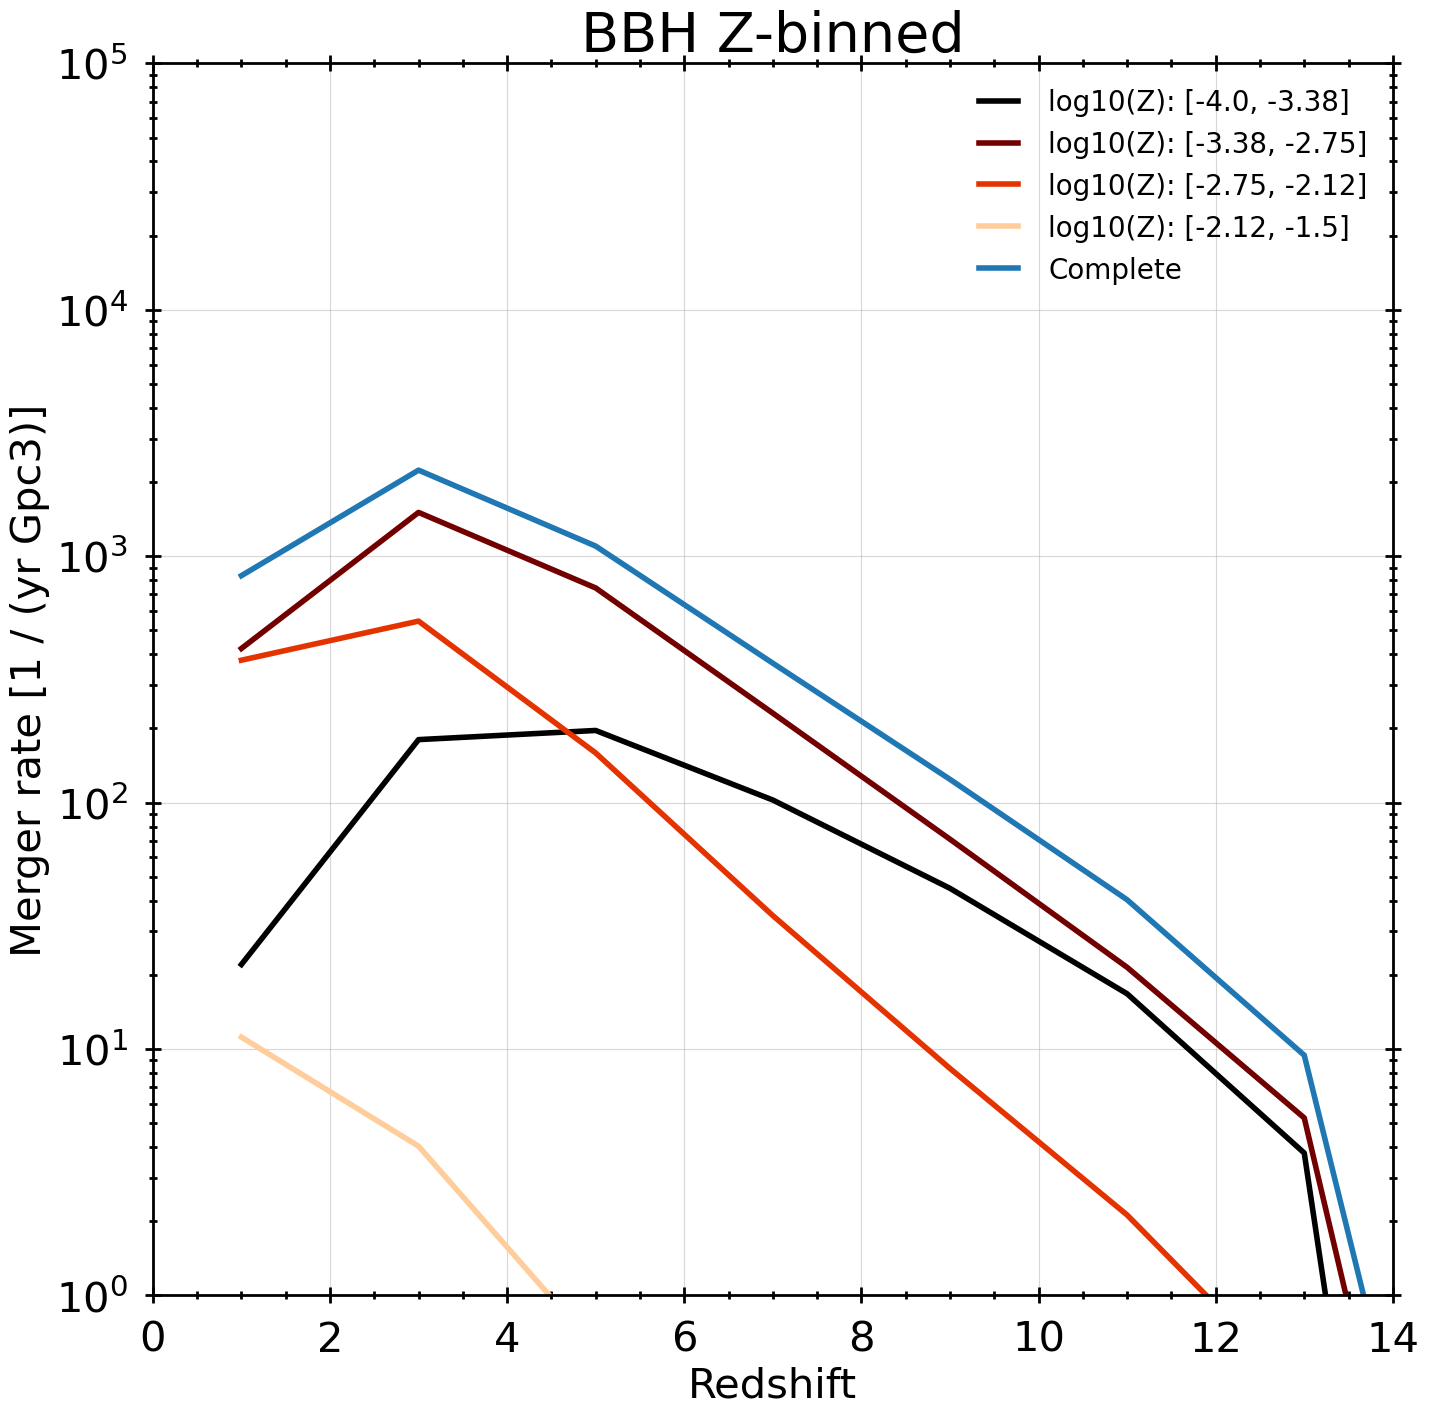

In [9]:
import matplotlib.ticker as mticker


merger_fig, merger_ax = plt.subplots(1, 1)
# merger_ax.set_ylim(np.min(merger_ax_rates), np.max(merger_ax_rates))
merger_ax.yaxis.set_inverted(False)  # ensure not inverted

# restore auto ticks/labels
merger_ax.yaxis.set_major_locator(mticker.AutoLocator()) #from GPT. something was wrong with matplotlib
merger_ax.yaxis.set_major_formatter(mticker.ScalarFormatter())

# merger_ax.plot(
# np.round(fiducial_plotting_data['merger_ax_lookbacks'],2),
# np.sum(fiducial_plotting_data['merger_rates_binned_by_metallicities'],axis=0),
# label='Complete'
# )
color_bins = plt.cm.gist_heat(np.linspace(0, 0.9, fiducial_plotting_data['merger_rates_binned_by_metallicities'].shape[0]-1))
for bi in range(fiducial_plotting_data['merger_rates_binned_by_metallicities'].shape[0]-1):     
    merger_ax.plot(
        np.round(fiducial_plotting_data['redshifts'],2),
        fiducial_plotting_data['merger_rates_binned_by_metallicities'][bi],
        color=color_bins[bi],
        label=f'log10(Z): [{fiducial_plotting_data['merger_metallicity_bins'][bi]}, {fiducial_plotting_data['merger_metallicity_bins'][bi+1]}]'
    )
    # merger_ax.fill_between(
    #     np.round(fiducial_plotting_data['redshifts'],2),
    #     fiducial_plotting_data['merger_rates_binned_by_metallicities'][bi],
    #     color=color_bins[bi],
    #     alpha=0.1
    # )
    # merger_ax.plot(
    #     np.round(merger_ax_lookbacks,2),
    #     merger_rates_binned_by_delaytimes[bi],
    #     # label=f'log10(Z): [{merger_metallicity_bins[bi]}, {merger_metallicity_bins[bi+1]}]'
    # )

# complete_merger_ax.plot(
#     fiducial_plotting_data['redshifts'],
#     np.sum(fiducial_plotting_data['merger_rates_binned_by_metallicities'],axis=0)
# )

merger_ax.plot(
    fiducial_plotting_data['redshifts'],
    np.sum(fiducial_plotting_data['merger_rates_binned_by_metallicities'],axis=0),
    label='Complete'
)

# plt.plot(fiducial_plotting_data['redshifts'], np.sum(fiducial_plotting_data['all_weights'],axis=0))

merger_ax.set_xlabel('Redshift')
# complete_merger_ax.set_xlabel('Redshift')
# merger_ax.set_ylim(sorted(merger_ax.get_ylim()))
merger_ax.set_yscale('log')
# complete_merger_ax.set_yscale('log')

merger_ax.set_ylabel(f'Merger rate [{fiducial_plotting_data['y_units']}]')
merger_ax.legend()
merger_ax.set_title(f'{TYPES} Z-binned')
# complete_merger_ax.set_title('Complete rate')

merger_ax.set_xlim(0, 14)
merger_ax.set_ylim(1,10e4)
# complete_merger_ax.set_xlim(0, 10)
# complete_merger_ax.set_ylim(1,10000)
merger_fig.savefig('merger rates.png')
